# 03 — Model Training

Trains anomaly detectors on **benign-only** spectral windows using the same helpers as `main.py`.

| Model | Notes |
|-------|-------|
| VAE | Deep generative — weight may be 0 after tuning |
| Isolation Forest | Tree ensemble |
| ECOD | Primary detector (tuned weight ~0.75) |
| COPOD / HBOS | Trained; often zero weight after tuning |

> **Deep SVDD** is implemented in `src/models/deep_svdd.py` but excluded from the ensemble (inverted validation AUROC on spectral features).

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.pipeline_helpers import (
    build_ensemble_models,
    train_detectors,
    calibrate_all_detectors,
    score_all_models,
)
from nb_common import (
    NotebookSettings, load_project_config, load_dataframe,
    build_splits, load_cached_splits, scale_splits,
    save_notebook_artifacts, split_summary, setup_notebook,
)

SETTINGS = NotebookSettings(use_sample=True, use_cache=True)
cfg = load_project_config(SETTINGS)
setup_notebook(cfg)
MODELS_DIR = SETTINGS.resolve_output_dir() / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load Splits

In [2]:
splits = load_cached_splits(SETTINGS, cfg)
if splits is None:
    df = load_dataframe(SETTINGS, cfg)
    splits = build_splits(SETTINGS, cfg, df)
print(split_summary(splits))

Train : 87 windows (benign only)
Val   : 33 windows (45.5% attack)
Test  : 35 windows (45.7% attack)
Features: 90


## 3. Scale Features

In [3]:
X_train, X_val, X_test, preprocessor = scale_splits(splits, MODELS_DIR)
y_val, y_test = splits['y_val'], splits['y_test']
print(f'Train {X_train.shape} | Val {X_val.shape} | Test {X_test.shape}')

Train (87, 90) | Val (33, 90) | Test (35, 90)


## 4. Train Models

In [4]:
models = build_ensemble_models(cfg, X_train.shape[1])
train_detectors(models, X_train, cfg, X_val=X_val)
calibrate_all_detectors(models, X_val, y_val)
print('Trained:', list(models.keys()))

Trained: ['vae', 'isolation_forest', 'ecod', 'copod', 'hbos']


## 5. Score Validation & Test

In [5]:
val_scores = score_all_models(models, X_val)
test_scores = score_all_models(models, X_test)
for name, s in test_scores.items():
    print(f'{name:20s} min={s.min():.3f}  max={s.max():.3f}  mean={s.mean():.3f}')

vae                  min=0.000  max=1.000  mean=0.568
isolation_forest     min=0.000  max=1.000  mean=0.573
ecod                 min=0.000  max=1.000  mean=0.541
copod                min=0.000  max=1.000  mean=0.549
hbos                 min=0.143  max=1.000  mean=0.720


## 6. Score Distributions

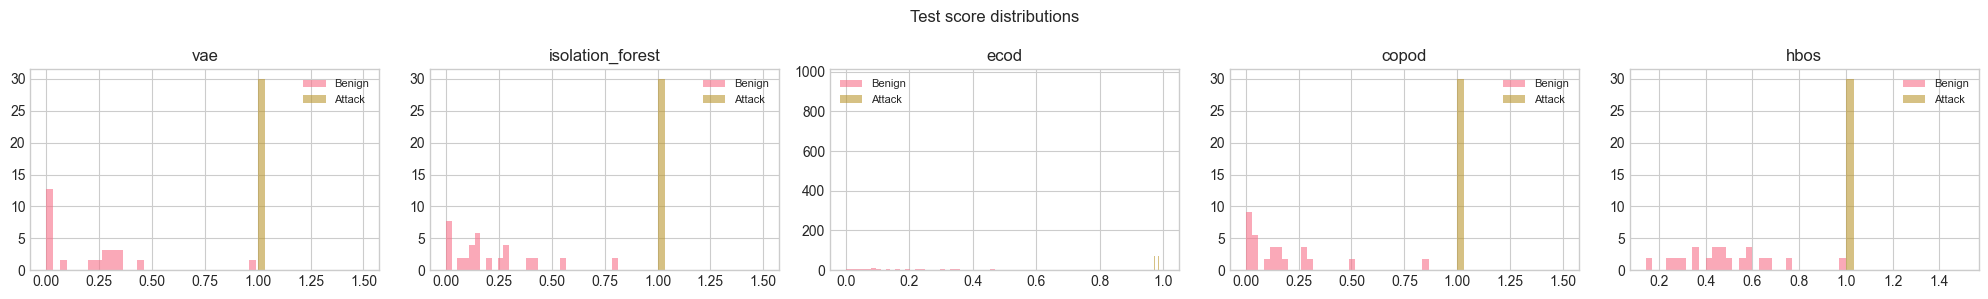

In [6]:
fig, axes = plt.subplots(1, len(test_scores), figsize=(4 * len(test_scores), 3))
if len(test_scores) == 1:
    axes = [axes]
for ax, (name, scores) in zip(axes, test_scores.items()):
    ax.hist(scores[y_test == 0], bins=30, alpha=0.6, label='Benign', density=True)
    if y_test.sum():
        ax.hist(scores[y_test == 1], bins=30, alpha=0.6, label='Attack', density=True)
    ax.set_title(name)
    ax.legend(fontsize=8)
plt.suptitle('Test score distributions')
plt.tight_layout()
plt.show()

## 7. Save Models & Artifacts

In [7]:
models['vae'].save(str(MODELS_DIR / 'vae.pt'))
models['isolation_forest'].save(str(MODELS_DIR / 'if.pkl'))
models['ecod'].save(str(MODELS_DIR / 'ecod.pkl'))
if 'copod' in models:
    models['copod'].save(str(MODELS_DIR / 'copod.pkl'))
if 'hbos' in models:
    models['hbos'].save(str(MODELS_DIR / 'hbos.pkl'))

save_notebook_artifacts({
    'val_scores': val_scores,
    'test_scores': test_scores,
    'y_val': y_val,
    'y_test': y_test,
    'lab_val': splits.get('lab_val'),
    'lab_test': splits['lab_test'],
    'test_timestamps': splits['test_timestamps'],
    'val_timestamps': splits.get('val_timestamps', splits['test_timestamps']),
    'feat_names': splits['feat_names'],
    'settings': SETTINGS,
})
print('Models and notebook_scores.joblib saved')

Models and notebook_scores.joblib saved
